# Classificazione reti neurali con IRIS

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.utils import to_categorical

# 1. Introduzione dataset IRIS

# 2. Preprocessing e caricamento dei dati

In [4]:
# 1. Caricamento dei dati
iris = load_iris()
X, y = iris.data, iris.target

# 2. Standardizzazione per velocizzare il Gradient Descent
scaler = StandardScaler()
X = scaler.fit_transform(X)

# 3. Trasformazione in One-hot Encoding
y = to_categorical(y)

# 4. Split dei dati: isoliamo il 20% per il test finale
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Dataset preparato:\n- Train set: {X_train.shape[0]} campioni\n- Test set: {X_test.shape[0]} campioni")


Dataset preparato:
- Train set: 120 campioni
- Test set: 30 campioni


# 3. Architettura Sequential con Keras
Costruiamo la rete impilando i layer. Useremo:
Un layer nascosto con attivazione **ReLU** (per evitare il problema del *vanishing gradient*).
Un layer di output con **Softmax**, ideale per ottenere probabilità nette tra classi mutuamente esclusive (la somma delle probabilità in uscita sarà 1).


In [21]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense 

# Costruzione del modello
model = Sequential([
    Dense(10, activation ="relu", input_shape=(4,)), # Layer nascosto con 10 neuroni
    Dense(3, activation ="softmax")                   # Layer di 3 output classici
])

model.compile(optimizer="adam",
              loss = "categorical_crossentropy",
              metrics = ["accuracy"])

model.summary()

c:\Users\chian\Desktop\Programmi Python\Modulo_4\.venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 10)             │            50 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 83 (332.00 B)

 Trainable params: 83 (332.00 B)

 Non-trainable params: 0 (0.00 B)

# 4. Training e Monitoraggio Visivo 

In [22]:
# addestramento
history = model.fit(X_train, y_train,
                    epochs=100,
                    batch_size=8,
                    validation_split=0.2, # creazione di un validation set interno
                    verbose=0
                    )

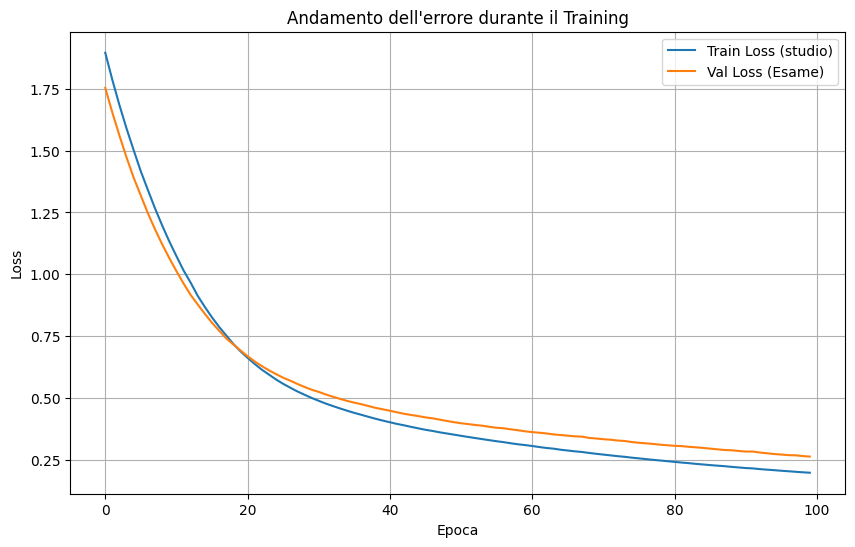

In [23]:
# visualizzazione delle curve di loss
plt.figure(figsize=(10,6))
plt.plot(history.history["loss"], label="Train Loss (studio)")
plt.plot(history.history["val_loss"], label="Val Loss (Esame)")
plt.title("Andamento dell'errore durante il Training")
plt.xlabel("Epoca")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()


# in questo caso si vede che il passo è troppo veloce e il modello rimbalza, quindi abbassiamo a 100

c:\Users\chian\Desktop\Programmi Python\Modulo_4\.venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Accuratezza finale sul Test Set: 100.00


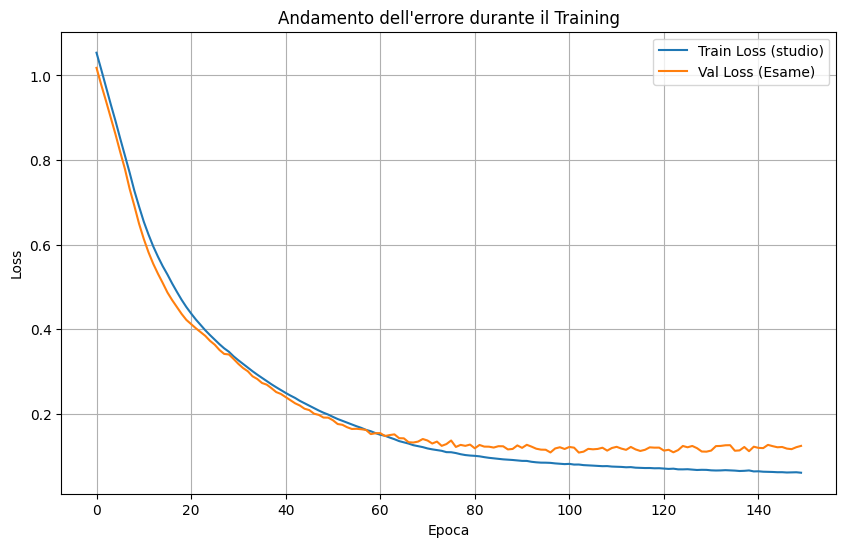

In [ ]:
# soluzione proposta: aggiunta di profondità

# Costruzione del modello
model_deep = Sequential([
    Dense(10, activation ="relu", input_shape=(4,)), # Layer nascosto con 10 neuroni
    Dense(8, activation ="relu"),                   # Layer aggiuntivo
    Dense(3, activation="softmax")
])

model_deep.compile(optimizer="adam",
              loss = "categorical_crossentropy",
              metrics = ["accuracy"])

# Training
history_deep = model_deep.fit(X_train, y_train, epochs=150, batch_size = 8, validation_split=0.2, verbose =0)

# Validazione
loss, acc = model_deep.evaluate(X_test, y_test, verbose=0.2)
print(f"Accuratezza finale sul Test Set: {acc*100:.2f}")

# Visualizzazione delle curve di loss

plt.figure(figsize=(10,6))
plt.plot(history_deep.history["loss"], label="Train Loss (studio)")
plt.plot(history_deep.history["val_loss"], label="Val Loss (Esame)")
plt.title("Andamento dell'errore durante il Training")
plt.xlabel("Epoca")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()


# Esercizio: aggiunta di un ulteriore layer nascosto con relu

c:\Users\chian\Desktop\Programmi Python\Modulo_4\.venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Accuratezza finale sul Test Set: 100.00


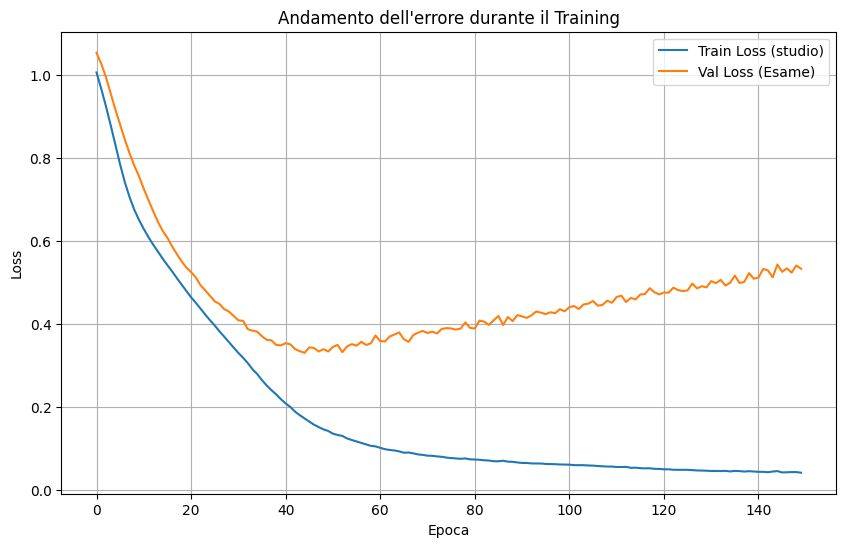

In [26]:
# aggiunta ulteriore layer

# Costruzione del modello
model_final = Sequential([
    Dense(10, activation ="relu", input_shape=(4,)), # Layer nascosto con 10 neuroni
    Dense(8, activation ="relu"),                    # Layer aggiuntivo
    Dense(8, activation ="relu"),                    # Ulteriore layer nascosto
    Dense(3, activation="softmax")
])

model_final.compile(optimizer="adam",
              loss = "categorical_crossentropy",
              metrics = ["accuracy"])

# Training
history_final = model_final.fit(X_train, y_train, epochs=150, batch_size = 8, validation_split=0.2, verbose =0)

# Validazione
loss, acc = model_final.evaluate(X_test, y_test, verbose=0.2)
print(f"Accuratezza finale sul Test Set: {acc*100:.2f}")

# Visualizzazione delle curve di loss

plt.figure(figsize=(10,6))
plt.plot(history_final.history["loss"], label="Train Loss (studio)")
plt.plot(history_final.history["val_loss"], label="Val Loss (Esame)")
plt.title("Andamento dell'errore durante il Training")
plt.xlabel("Epoca")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()